# House Price Prediction using Linear Regression

### Problem

The goal of this project is to predict the selling price of a house based on its features.


We will perform:

1. Data Understanding
2. Data Cleaning
3. EDA && Feature Engineering
4. DATA VISUALIZATION
5. TRAIN TEST SPLIT
6. FEATURE SCALING
7. LINEAR REGRESSION

## PHASE 1 : SETUP & DATA UNDERSTANDING

In [1]:
# Import pandas library
import pandas as pd

In [2]:
# Load the dataset
df = pd.read_csv("house_prices_dataset2.csv")

In [3]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7229300521,20141013T000000,231300.0,2,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [4]:
df.shape

(21613, 21)

df.columns

In [5]:
# Select Required Columns
house = df[
    [
        "price",
        "bedrooms",
        "bathrooms",
        "sqft_living",
        "floors",
        "grade",
        "condition",
        "sqft_basement",
        "sqft_above",
        "waterfront",
        "yr_built"
    ]
]

In [6]:
print(house.head())
print(house.shape)

      price  bedrooms  bathrooms  sqft_living  floors  grade  condition  \
0  231300.0         2       1.00         1180     1.0      7          3   
1  538000.0         3       2.25         2570     2.0      7          3   
2  180000.0         2       1.00          770     1.0      6          3   
3  604000.0         4       3.00         1960     1.0      7          5   
4  510000.0         3       2.00         1680     1.0      8          3   

   sqft_basement  sqft_above  waterfront  yr_built  
0              0        1180           0      1955  
1            400        2170           0      1951  
2              0         770           0      1933  
3            910        1050           0      1965  
4              0        1680           0      1987  
(21613, 11)


In [7]:
house.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          21613 non-null  float64
 1   bedrooms       21613 non-null  int64  
 2   bathrooms      21613 non-null  float64
 3   sqft_living    21613 non-null  int64  
 4   floors         21613 non-null  float64
 5   grade          21613 non-null  int64  
 6   condition      21613 non-null  int64  
 7   sqft_basement  21613 non-null  int64  
 8   sqft_above     21613 non-null  int64  
 9   waterfront     21613 non-null  int64  
 10  yr_built       21613 non-null  int64  
dtypes: float64(3), int64(8)
memory usage: 1.8 MB


In [8]:
house.describe()

,price,bedrooms,bathrooms,sqft_living,floors,grade,condition,sqft_basement,sqft_above,waterfront,yr_built
count,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,5.400886e+05,3.370795,2.114757,2079.899736,1.494309,7.656873,3.409430,291.509045,1788.390691,0.007542,1971.005136
std,3.671268e+05,0.930105,0.770163,918.440897,0.539989,1.175459,0.650743,442.575043,828.090978,0.086517,29.373411
min,7.500000e+04,0.000000,0.000000,290.000000,1.000000,1.000000,1.000000,0.000000,290.000000,0.000000,1900.000000
25%,3.219500e+05,3.000000,1.750000,1427.000000,1.000000,7.000000,3.000000,0.000000,1190.000000,0.000000,1951.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,1.500000,7.000000,3.000000,0.000000,1560.000000,0.000000,1975.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,2.000000,8.000000,4.000000,560.000000,2210.000000,0.000000,1997.000000
max,7.700000e+06,33.000000,8.000000,13540.000000,3.500000,13.000000,5.000000,4820.000000,9410.000000,1.000000,2015.000000


In [9]:
pd.set_option("display.float_format", "{:.2f}".format)
house.describe()

,price,bedrooms,bathrooms,sqft_living,floors,grade,condition,sqft_basement,sqft_above,waterfront,yr_built
count,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00
mean,540088.58,3.37,2.11,2079.90,1.49,7.66,3.41,291.51,1788.39,0.01,1971.01
std,367126.83,0.93,0.77,918.44,0.54,1.18,0.65,442.58,828.09,0.09,29.37
min,75000.00,0.00,0.00,290.00,1.00,1.00,1.00,0.00,290.00,0.00,1900.00
25%,321950.00,3.00,1.75,1427.00,1.00,7.00,3.00,0.00,1190.00,0.00,1951.00
50%,450000.00,3.00,2.25,1910.00,1.50,7.00,3.00,0.00,1560.00,0.00,1975.00
75%,645000.00,4.00,2.50,2550.00,2.00,8.00,4.00,560.00,2210.00,0.00,1997.00
max,7700000.00,33.00,8.00,13540.00,3.50,13.00,5.00,4820.00,9410.00,1.00,2015.00


## PHASE 2: DATA CLEANING
In this phase, we checked the dataset for:

- Missing Values
- Duplicate Rows

In [10]:
# Check Missing Value
house.isnull().sum()

price            0
bedrooms         0
bathrooms        0
sqft_living      0
floors           0
grade            0
condition        0
sqft_basement    0
sqft_above       0
waterfront       0
yr_built         0
dtype: int64

In [11]:
# Check Duplicate Value
house.duplicated().sum()


np.int64(36)

In [12]:
# Remove Duplicate Rows
house = house.drop_duplicates()

house.duplicated().sum()

np.int64(0)

In [13]:
house.dtypes

price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
floors           float64
grade              int64
condition          int64
sqft_basement      int64
sqft_above         int64
waterfront         int64
yr_built           int64
dtype: object

In [14]:

#house["floors"] = house["floors"].astype(int)
#house["bathrooms"] = house["bathrooms"].astype(int)

In [15]:
# Separate Numerical and Categorical Columns

#numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns
#categorical_columns = df.select_dtypes(include=["object"]).columns

In [16]:
# Display Numerical Columns
#numerical_columns

In [17]:
# Display Categorical Columns

#categorical_columns

## PHASE 3: EXPLORATORY DATA ANALYSIS (EDA)

In [18]:
house.head()

,price,bedrooms,bathrooms,sqft_living,floors,grade,condition,sqft_basement,sqft_above,waterfront,yr_built
0,231300.00,2,1.00,1180,1.00,7,3,0,1180,0,1955
1,538000.00,3,2.25,2570,2.00,7,3,400,2170,0,1951
2,180000.00,2,1.00,770,1.00,6,3,0,770,0,1933
3,604000.00,4,3.00,1960,1.00,7,5,910,1050,0,1965
4,510000.00,3,2.00,1680,1.00,8,3,0,1680,0,1987


In [19]:
# Check Avg house price ,min price & max price
house["price"].describe()

count     21577.00
mean     540223.37
std      367374.63
min       75000.00
25%      321500.00
50%      450000.00
75%      645000.00
max     7700000.00
Name: price, dtype: float64

In [20]:
# Avg House Price by No of Bedrooms
house.groupby("bedrooms")["price"].mean()

bedrooms
0     409503.85
1     317642.88
2     401385.98
3     466251.34
4     635482.06
5     787092.92
6     827857.83
7     951184.66
8    1105076.92
9     893999.83
10    819333.33
11    520000.00
33    640000.00
Name: price, dtype: float64

In [21]:
# Average Sale Price by floor
df.groupby("floors")["price"].mean().sort_values(ascending=False)

floors
2.50   1060346.49
3.50    933312.50
2.00    648891.16
3.00    582526.04
1.50    558980.64
1.00    442181.51
Name: price, dtype: float64

In [22]:
# Number of Houses near waterfront
df["waterfront"].value_counts()

waterfront
0    21450
1      163
Name: count, dtype: int64


### PHASE 4 : DATA VISUALIZATION

Visualize the data to better understand:

- Distribution of house prices
- Relationship between features and SalePrice
- Category-wise average selling price

In [23]:
import matplotlib.pyplot as plt

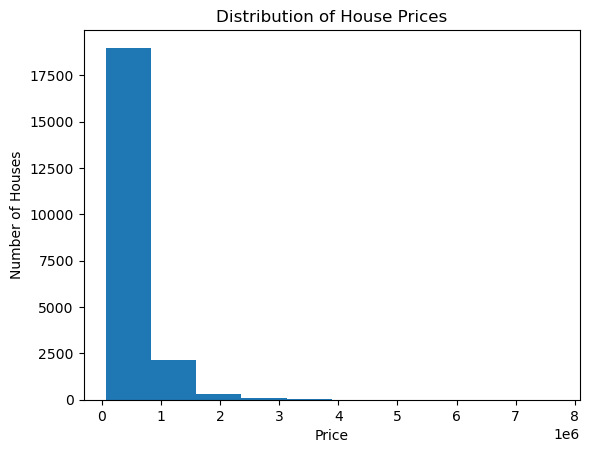

In [24]:
# Histogram of SalePrice
plt.hist(house["price"], bins=10)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Number of Houses")

plt.show()

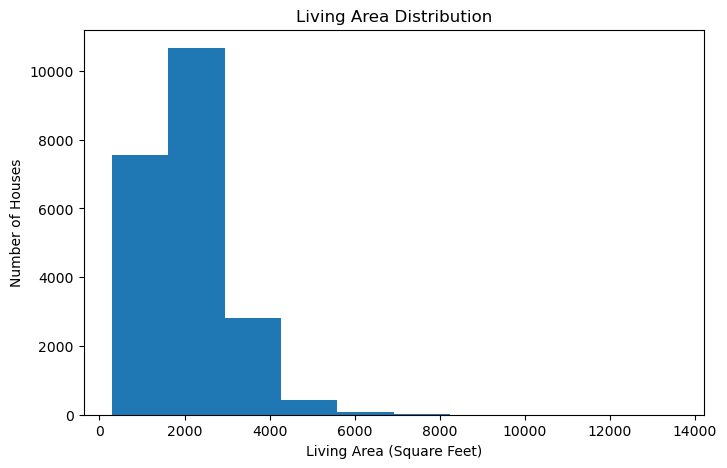

In [25]:
# Distribution of Living Area
plt.figure(figsize=(8,5))

plt.hist(house["sqft_living"], bins=10)
plt.title("Living Area Distribution")
plt.xlabel("Living Area (Square Feet)")
plt.ylabel("Number of Houses")

plt.show()

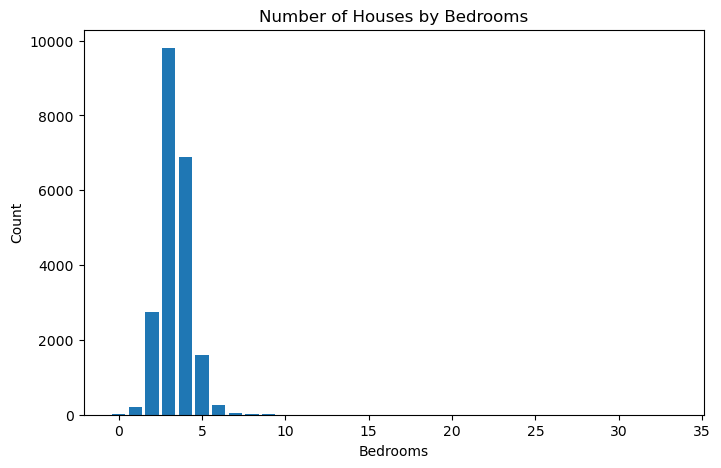

In [27]:
# Number of Houses by Bedrooms
bedroom_count = house["bedrooms"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(bedroom_count.index, bedroom_count.values)
plt.title("Number of Houses by Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Count")

plt.show()

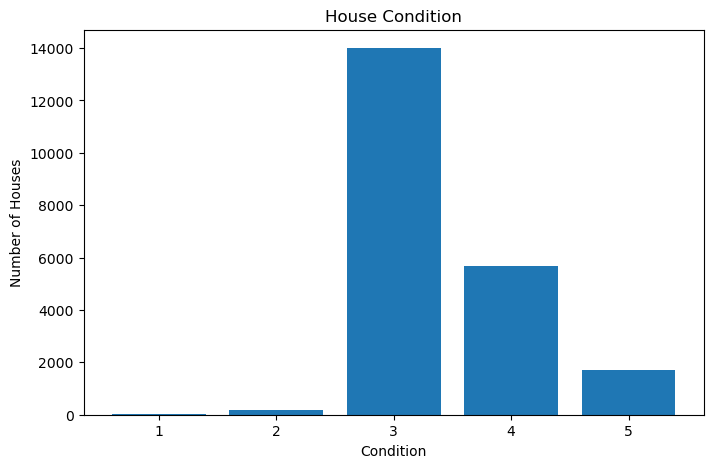

In [28]:
# House Condition Distribution
condition_count = house["condition"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(condition_count.index, condition_count.values)
plt.title("House Condition")
plt.xlabel("Condition")
plt.ylabel("Number of Houses")

plt.show()

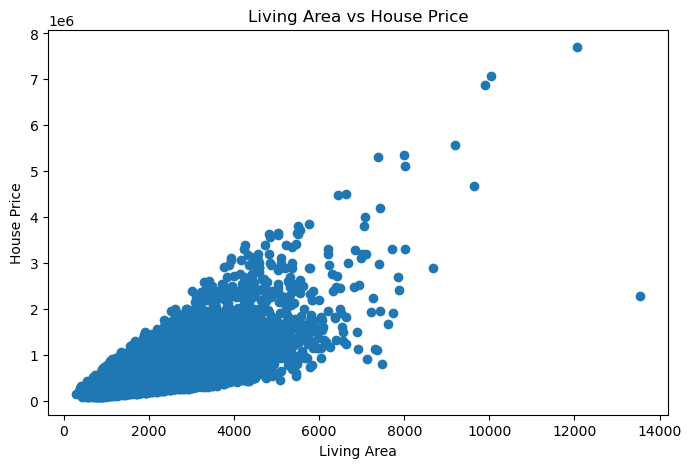

In [29]:
# Relationship Between Living Area and Price
plt.figure(figsize=(8,5))

plt.scatter(house["sqft_living"], house["price"])
plt.title("Living Area vs House Price")
plt.xlabel("Living Area")
plt.ylabel("House Price")

plt.show()

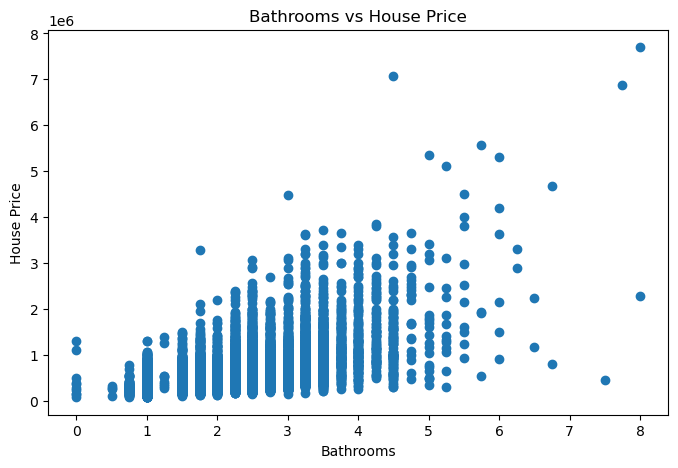

In [30]:
# Relationship Between Bathrooms and Price
plt.figure(figsize=(8,5))

plt.scatter(house["bathrooms"], house["price"])

plt.title("Bathrooms vs House Price")
plt.xlabel("Bathrooms")
plt.ylabel("House Price")

plt.show()

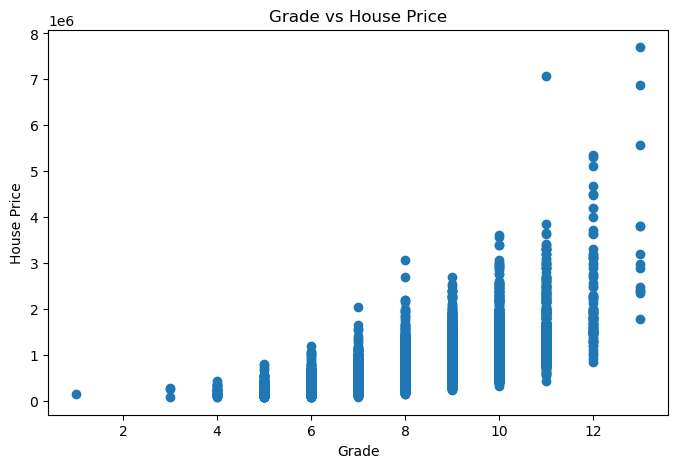

In [31]:
# Relationship Between Grade and Price
plt.figure(figsize=(8,5))

plt.scatter(house["grade"], house["price"])
plt.title("Grade vs House Price")
plt.xlabel("Grade")
plt.ylabel("House Price")

plt.show()

## PHASE 5 : TRAIN TEST SPLIT


Before training the model, we separate:

- Features (X)
- Target (y)

### Features (Independent Variables)

- OverallQual
- GrLivArea
- BedroomAbvGr
- GarageCars
- GarageArea
- TotalBsmtSF
- FullBath
- YearBuilt
- Neighborhood
- KitchenQual

### Target (Dependent Variable)

- SalePrice

After separating the data, we split it into:

- Training Data (80%)
- Testing Data (20%)



In [32]:
# Select Features (X)
X = house.drop("price", axis=1)
X.head()

,bedrooms,bathrooms,sqft_living,floors,grade,condition,sqft_basement,sqft_above,waterfront,yr_built
0,2,1.00,1180,1.00,7,3,0,1180,0,1955
1,3,2.25,2570,2.00,7,3,400,2170,0,1951
2,2,1.00,770,1.00,6,3,0,770,0,1933
3,4,3.00,1960,1.00,7,5,910,1050,0,1965
4,3,2.00,1680,1.00,8,3,0,1680,0,1987


In [33]:
# Select Target (y)
y = house["price"]
y.head()

0   231300.00
1   538000.00
2   180000.00
3   604000.00
4   510000.00
Name: price, dtype: float64

In [34]:
from sklearn.model_selection import train_test_split

In [35]:
# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [36]:
X_train.shape

(17261, 10)

In [37]:
X_test.shape

(4316, 10)


## PHASE 6: FEATURE SCALING

The selected features have different ranges.


Machine Learning algorithms perform better when all features are on a similar scale.

we use **StandardScaler** to standardize the features.


In [38]:
from sklearn.preprocessing import StandardScaler

In [39]:
scaler = StandardScaler()

In [40]:
# Scale Training & Testing Data
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [41]:
X_train

array([[-1.51405035, -1.4467574 , -0.69758494, ..., -0.98646376,
        -0.08711247,  0.30641216],
       [ 0.69816644, -1.4467574 ,  0.13950704, ...,  0.50270916,
        -0.08711247, -2.38875741],
       [ 0.69816644,  1.14687647,  0.25909161, ...,  0.44266187,
        -0.08711247,  0.9546175 ],
       ...,
       [-1.51405035,  0.17426377, -0.18663269, ..., -0.93842592,
        -0.08711247,  0.0334836 ],
       [-2.62015875, -1.77096164, -1.84994533, ..., -1.69502184,
        -0.08711247, -0.27356104],
       [ 0.69816644,  0.82267223, -0.15401872, ...,  0.17845377,
        -0.08711247,  0.64757286]], shape=(17261, 10))

In [42]:
X_train.shape

(17261, 10)

## PHASE 7: LINEAR REGRESSION
Build a Linear Regression model to predict house prices based on the selected features.


In [43]:
from sklearn.linear_model import LinearRegression

In [44]:
# Train the Model
model = LinearRegression()

model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [45]:
# Predict House Prices
y_pred = model.predict(X_test)

y_pred

array([344495.41748017, 378746.71957009, 478955.44537067, ...,
       535444.82170417, 323336.7815357 , 835601.24803727], shape=(4316,))